# Estimate diameter from phase function

In [2]:
import requests
import time
import io
import os

import numpy as np
import pandas as pd

import rocks

from figure_mask import compute_mask, print_statistics

import matplotlib.pyplot as plt
from matplotlib.patches import (Circle, Ellipse)

from sklearn.model_selection import train_test_split

import pickle
# import seaborn as sns
# sns.set_context("poster")

### Combination BFT & SSOFT

In [3]:
cols = [
    "sso_number",
    "sso_name",
    "sso_class",
    "albedo.value",
    "diameter.value",
]

# Read BFT with rocks
bft = rocks.load_bft(columns=cols)

In [4]:
# bft[bft["spins.1.period.value"] == bft["spins.1.period.value"]].groupby("spins.1.period_flag").count()

In [5]:
print(
    "{:,} diameters available in the BFT".format(len(bft[bft["diameter.value"].notna()]))
)

149,478 diameters available in the BFT


In [6]:
# You need SSOFT version 2024.09
# see fink_spins/generate_data.py
data_fink = "../../"
ssoft = pd.read_parquet(os.path.join(data_fink, "data", "ztf", "sso_ZTF.parquet"))

In [7]:
flavor = "SHG1G2"
filt = 'r'

## Comparison to literature

In [8]:
# Keep only known periods 1 in the BFT
data = ssoft.merge(bft, left_on="name", right_on="sso_name", how="left")
data = data[data["albedo.value"].notna()]

# sort by number of observations
data = data.sort_values("n_obs", ascending=False)
# data = data.sort_values(f'{flavor}_rms', ascending=False)

col_display = [
    "sso_number",
    "sso_name",
    "n_obs",
    "sso_class",
    "albedo.value",
    f"{flavor}_period",
    f"{flavor}_rms",
]

if flavor == "SHG1G2":
    col_display.append(f"{flavor}_R")

cond = data.sso_class.str.contains("Inner")
# cond = (data['spins.1.technique']=='LCI') & ( np.abs(data['spins.1.period.value']-data['SSHG1G2_period']) < 0.1)

data.loc[cond, col_display].head(5)

,sso_number,sso_name,n_obs,sso_class,albedo.value,SHG1G2_period,SHG1G2_rms,SHG1G2_R
63906,5518,Mariobotta,451.0,MB>Inner,0.2012,33.183693,0.169943,0.789760
84016,21814,Shanawolff,431.0,MB>Inner,0.2405,2.499411,0.056240,0.865430
30332,1928,Summa,409.0,MB>Inner,0.1469,48.055374,0.116187,0.300000
51067,2200,Pasadena,405.0,MB>Inner,0.1962,20.530388,0.068762,0.818853
91906,5350,Epetersen,394.0,MB>Inner,0.2233,4.549254,0.111522,0.746113


In [9]:
print(
    "{:,} albedo available in the BFT x Fink".format(
        len(data[data["albedo.value"].notna()])
    )
)

77,121 albedo available in the BFT x Fink


### Mask

It is not obvious yet what are the criteria for good period estimation, so let's stick with masks defined for sHG1G2

In [10]:
maskFINK_inter = compute_mask(
    ssoft, thres_spin=1e-3, thres_phase=1e-3, R_min=0.30, model="FINK", kind="inter"
)
maskFINK_union = compute_mask(
    ssoft, thres_spin=1e-3, thres_phase=1e-3, R_min=0.30, model="FINK", kind="union"
)

for model in ["HG", "HG1G2", "SHG1G2", "FINK"]:
    print_statistics(ssoft, model)
    print()

mask = maskFINK_union
mask = maskFINK_inter
print(sum(mask))

  All data       : 140559  (100.00%)
  Mask HG (g∩r) : 137746  ( 98.00%)
  Mask HG (gUr) : 137752  ( 98.00%)

  All data       : 140559  (100.00%)
  Mask HG1G2 (g∩r) :  57578  ( 40.96%)
  Mask HG1G2 (gUr) : 101207  ( 72.00%)

  All data       : 140559  (100.00%)
  Mask SHG1G2 (g∩r) :  76798  ( 54.64%)
  Mask SHG1G2 (gUr) : 114519  ( 81.47%)

  All data       : 140559  (100.00%)
  Mask FINK (g∩r) :  57198  ( 40.69%)
  Mask FINK (gUr) :  95470  ( 67.92%)

57198


In [11]:
print(
    "{:,} albedo available in the MASK(BFT x Fink)".format(
        len(data[data["albedo.value"].notna()][mask])
    )
)

33,447 albedo available in the MASK(BFT x Fink)


/tmp/ipykernel_18958/3483294913.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  len(data[data["albedo.value"].notna()][mask])


### Period distribution

In [12]:
data.columns[data.columns.str.contains("SSH")]

Index(['SSHG1G2_fit', 'SSHG1G2_status', 'SSHG1G2_chi2red',
       'SSHG1G2_min_cos_lambda', 'SSHG1G2_mean_cos_lambda',
       'SSHG1G2_max_cos_lambda', 'SSHG1G2_rms', 'SSHG1G2_rms_g',
       'SSHG1G2_rms_r', 'SSHG1G2_median_error_phot',
       'SSHG1G2_median_error_phot_1', 'SSHG1G2_median_error_phot_2',
       'SSHG1G2_alpha0', 'SSHG1G2_dalpha0', 'SSHG1G2_delta0',
       'SSHG1G2_ddelta0', 'SSHG1G2_period', 'SSHG1G2_err_period',
       'SSHG1G2_a_b', 'SSHG1G2_da_b', 'SSHG1G2_a_c', 'SSHG1G2_da_c',
       'SSHG1G2_phi0', 'SSHG1G2_dphi0', 'SSHG1G2_H_g', 'SSHG1G2_dH_g',
       'SSHG1G2_G1_g', 'SSHG1G2_dG1_g', 'SSHG1G2_G2_g', 'SSHG1G2_dG2_g',
       'SSHG1G2_H_r', 'SSHG1G2_dH_r', 'SSHG1G2_G1_r', 'SSHG1G2_dG1_r',
       'SSHG1G2_G2_r', 'SSHG1G2_dG2_r', 'SSHG1G2_period_chi2red',
       'SSHG1G2_obliquity', 'SSHG1G2_alpha0_alt', 'SSHG1G2_delta0_alt',
       'SSHG1G2_flag'],
      dtype='object')

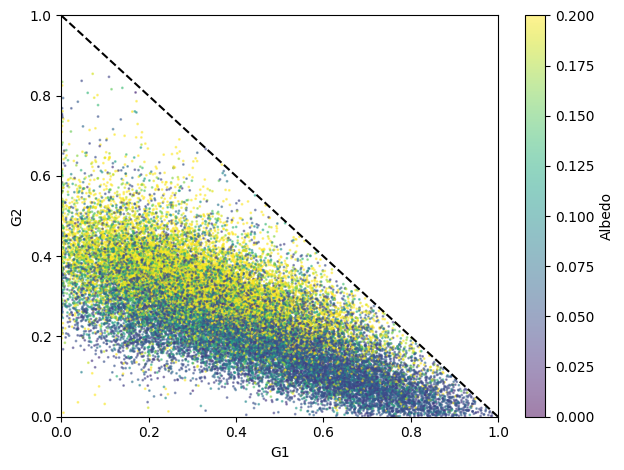

In [13]:
fig, ax = plt.subplots()  # figsize=(14, 8))

filt = "g"
im = ax.scatter(
    data.loc[mask, f"{flavor}_G1_{filt}"],
    data.loc[mask, f"{flavor}_G2_{filt}"],
    c=data.loc[mask, "albedo.value"],
    vmin=0,
    vmax=0.2,
    s=1,
    alpha=0.5,
)

x = np.linspace(0, 1, 10)
ax.plot(x, 1 - x, color="black", linestyle="--")

cbar = fig.colorbar(im, label="Albedo")

# Axes
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_ylabel("G2")
ax.set_xlabel("G1")

fig.tight_layout()

## Regression


In [14]:
cond = (data[f"{flavor}_G1_{filt}"].notna()) & (data[f"{flavor}_G2_{filt}"].notna())
mask = mask & cond


In [15]:
# Prepare data
X = data.loc[mask, [f"{flavor}_G1_{filt}", f"{flavor}_G2_{filt}"] ].to_numpy()
y = data.loc[mask, "albedo.value"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [16]:
# # Compute regression
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import RadiusNeighborsRegressor



for reg in [LinearRegression(), RadiusNeighborsRegressor(radius=0.05)]:
# for reg in [LinearRegression()]:
    model = make_pipeline(reg)
    model[0].fit(X_train, y_train)
    score = model[0].score(X_test, y_test)
    print( score )

0.25243934153036607
0.30200502720250366


In [17]:
# # Compute regression
from sklearn.linear_model import LinearRegression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

reg = LinearRegression().fit(X_train, y_train)
print(reg.score(X_test, y_test))


0.25243934153036607


In [18]:
from sklearn.neighbors import RadiusNeighborsRegressor, KNeighborsRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

neigh = RadiusNeighborsRegressor(radius=0.05)
reg = neigh.fit(X_train, y_train)
print(neigh.score(X_test, y_test))


neigh = KNeighborsRegressor(n_neighbors=50, weights='distance')
reg = neigh.fit(X_train, y_train)
print(neigh.score(X_test, y_test))

# save
# with open('model.pkl','wb') as f:
#     pickle.dump(neigh,f)


0.30200502720250366
0.2809941440287258


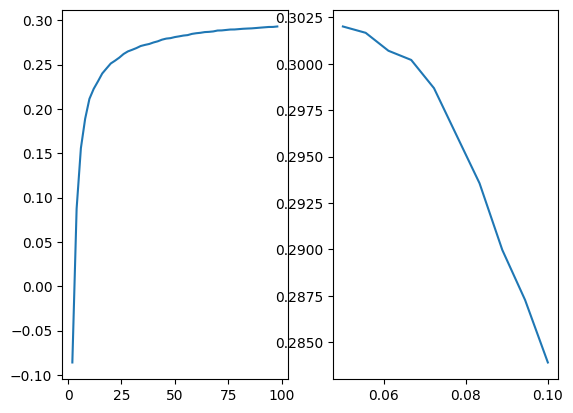

In [19]:
kns = range(2,100,2)
score = []
for kn in kns:
    neigh_t = KNeighborsRegressor(n_neighbors=kn, weights='distance')
    reg = neigh_t.fit(X_train, y_train)
    score.append( neigh_t.score(X_test, y_test))

krs = np.linspace(0.05, 0.10, 10)
score_r = []
for kr in krs:
    neigh_t = RadiusNeighborsRegressor(radius=kr)
    reg = neigh_t.fit(X_train, y_train)
    score_r.append( neigh_t.score(X_test, y_test))

fig, ax = plt.subplots(1,2)
ax[0].plot(kns, score)
ax[1].plot(krs, score_r)

In [20]:
# pv_pred = neigh.predict(X_test)
# pv_train = neigh.predict(X_train)

# pv_pred = reg.predict(X_test)
# pv_train = reg.predict(X_train)

In [21]:
# fig, ax = plt.subplots(1, 2, figsize=(10, 6))

# ax[0].hist( y_test-pv_pred, bins=40)
# ax[0].set_xlabel('albedo - prediction')

# ax[1].scatter( y_test, pv_pred, s=4, alpha=0.4)
# # ax[1].scatter( y_train, pv_train, s=4, alpha=0.1)
# xx = np.linspace(0,0.4,10)
# ax[1].plot(xx,xx, color='black', linestyle='--')

# ax[1].set_xlabel('albedo ref')
# ax[1].set_ylabel('albedo pred')
# ax[1].set_xlim(0,0.4)



In [22]:
# Build output map
N = 201
xy = np.array([(i, j) for j in np.linspace(0,1,num=N) for i in np.linspace(0,1,num=N)])
xy = np.tril(xy)

# z = np.tril(reg.predict(xy).reshape(N,N)[::-1])
# z = z+unity

unity = np.rot90(np.tril(np.full((N,N), 1)),3)
no_data = np.where(unity==0)

# z = reg.predict(xy).reshape(N,N)
z = neigh.predict(xy).reshape(N,N)
z[no_data] = np.nan

# z = np.triu(np.reverse(neigh.predict(xy).reshape(N,N)))


Text(0.5, 0, 'dG1, dG2')

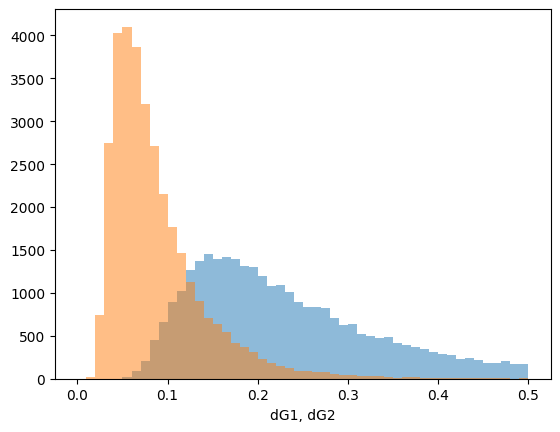

In [23]:
fig, ax = plt.subplots()

b = np.linspace(0,0.5, 51)
ax.hist( data.loc[mask, f"{flavor}_dG1_r"], bins=b, alpha=0.5)
ax.hist( data.loc[mask, f"{flavor}_dG2_r"], bins=b, alpha=0.5)
ax.set_xlabel('dG1, dG2')

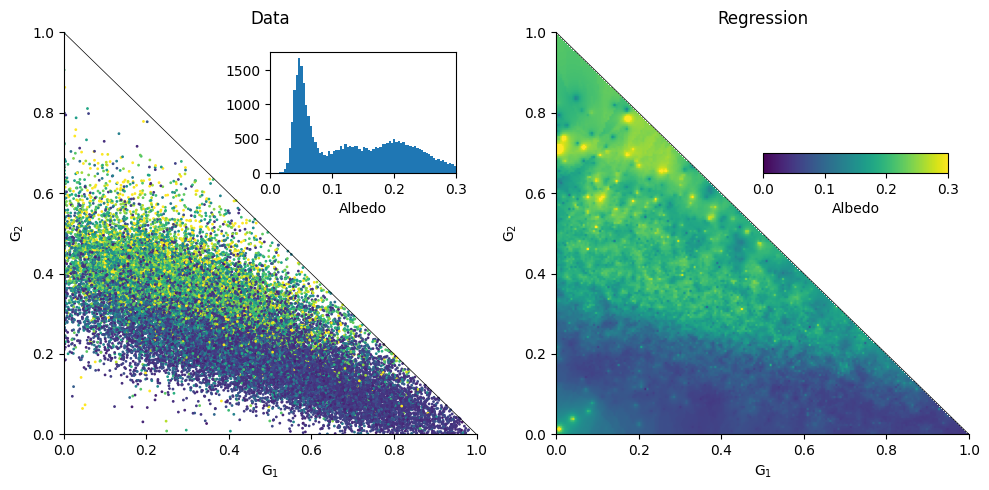

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

vmin, vmax = 0, 0.3

# --------------------------------------------------------------------------------
filt = "r"
im = ax[0].scatter(
    data.loc[mask, f"{flavor}_G1_{filt}"],
    data.loc[mask, f"{flavor}_G2_{filt}"],
    c=data.loc[mask, "albedo.value"],
    vmin=vmin,
    vmax=vmax,
    s=1,
    alpha=1,
)

# --------------------------------------------------------------------------------
axins = ax[0].inset_axes([0.5, 0.65, 0.45, 0.30])
axins.hist( data.loc[mask, "albedo.value"], range=(vmin,vmax), bins=80)
axins.set_xlabel("Albedo")
axins.set_xlim(vmin, vmax)

# --------------------------------------------------------------------------------
im = ax[1].imshow(z, extent=(0,1,0,1), origin='lower', vmin=vmin, vmax=vmax, aspect='auto', )
# cbaxes = ax[1].inset_axes( [0.8,0.4,0.05,0.5]) 
# cbar = fig.colorbar(im, cax=cbaxes, ticks=[0.,0.1,0.2,0.3], label="Albedo")
cbaxes = ax[1].inset_axes( [0.5,0.65,0.45,0.05]) 
cbar = fig.colorbar(im, cax=cbaxes, ticks=[0.,0.1,0.2,0.3], label="Albedo", orientation='horizontal')


# Typical uncertainty
# ell = Ellipse( (0.2,0.6), 0.17*2, 0.05*2, facecolor='none', edgecolor='white', linewidth=1)
# ax[1].add_patch(ell)



# --------------------------------------------------------------------------------
# Axes
x = np.linspace(0, 1, 10)
for a in ax:

    a.plot(x, 1 - x, color="black", linestyle="solid", linewidth=0.5)
    a.set_xlim(0, 1)
    a.set_ylim(0, 1)
    a.set_ylabel("G$_2$")
    a.set_xlabel("G$_1$")


ax[0].set_title("Data")
ax[1].set_title("Regression")

ax[0].spines[['right', 'top']].set_visible(False)
ax[1].spines[['right', 'top']].set_visible(False)

fig.tight_layout()
fig.savefig("/home/bcarry/G1G2_albedo_regression.png")

In [26]:
# save
with open('model.pkl','wb') as f:
    pickle.dump(neigh,f)
